# Hybrid Cross-Lingual Music Recommendation System

This notebook completes the project notebook by implementing:

- **Baseline lyrics recommender** using TF-IDF
- **Multilingual lyrics embeddings** with `sentence-transformers`
- **FAISS-based search** for scalable retrieval
- **Optional hybrid recommender** combining lyrics + audio features
- **Simple XAI layer** to explain why a recommendation was made
- **Optional 3D visualization** of the song embedding space

It is written to be **robust**:
- it tries multiple dataset paths,
- avoids building enormous full similarity matrices on the full dataset,
- uses sampling where needed,
- and gracefully skips optional sections when external files are missing.


In [ ]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from scipy import sparse

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)


In [ ]:
# Download required NLTK assets
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))
print("NLTK setup complete.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


NLTK setup complete.


## 1. Load lyrics dataset

Update `DATA_CANDIDATES` if your CSV is stored somewhere else.  
The expected lyrics dataset is the classic Spotify million song lyrics CSV with columns similar to:

- `artist`
- `song`
- `link`
- `text`


In [ ]:
DATA_CANDIDATES = [
    "spotify_millsongdata.csv",
    "spotify_songs.csv",
    "universal_top_spotify_songs.csv",
]

lyrics_path = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)

if lyrics_path is None:
    raise FileNotFoundError(
        "Could not find spotify_millsongdata.csv. "
        "Place it next to this notebook or update DATA_CANDIDATES."
    )

df = pd.read_csv(lyrics_path)
print("Loaded:", lyrics_path)
print("Shape:", df.shape)
df.head()

Loaded: spotify_millsongdata.csv
Shape: (57650, 4)


,artist,song,link,text
0,ABBA,Ahe's My Kind Of Girl,/a/abba/ahes+my+kind+of+girl_20598417.html,"Look at her face, it's a wonderful face \r\nAnd it means something special to me \r\nLook at the way that she smil..."
1,ABBA,"Andante, Andante",/a/abba/andante+andante_20002708.html,"Take it easy with me, please \r\nTouch me gently like a summer evening breeze \r\nTake your time, make it slow \r..."
2,ABBA,As Good As New,/a/abba/as+good+as+new_20003033.html,"I'll never know why I had to go \r\nWhy I had to put up such a lousy rotten show \r\nBoy, I was tough, packing all..."
3,ABBA,Bang,/a/abba/bang_20598415.html,"Making somebody happy is a question of give and take \r\nYou can learn how to show it so come on, give yourself a b..."
4,ABBA,Bang-A-Boomerang,/a/abba/bang+a+boomerang_20002668.html,"Making somebody happy is a question of give and take \r\nYou can learn how to show it so come on, give yourself a b..."


In [ ]:
# Basic inspection
print(df.columns.tolist())
print()
print(df.isnull().sum())


['artist', 'song', 'link', 'text']

artist    0
song      0
link      0
text      0
dtype: int64


In [ ]:
# Drop link if present
if "link" in df.columns:
    df = df.drop("link", axis=1)

df = df.dropna(subset=["artist", "song", "text"]).reset_index(drop=True)
print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (57650, 3)


,artist,song,text
0,ABBA,Ahe's My Kind Of Girl,"Look at her face, it's a wonderful face \r\nAnd it means something special to me \r\nLook at the way that she smil..."
1,ABBA,"Andante, Andante","Take it easy with me, please \r\nTouch me gently like a summer evening breeze \r\nTake your time, make it slow \r..."
2,ABBA,As Good As New,"I'll never know why I had to go \r\nWhy I had to put up such a lousy rotten show \r\nBoy, I was tough, packing all..."
3,ABBA,Bang,"Making somebody happy is a question of give and take \r\nYou can learn how to show it so come on, give yourself a b..."
4,ABBA,Bang-A-Boomerang,"Making somebody happy is a question of give and take \r\nYou can learn how to show it so come on, give yourself a b..."


Top 10 artists:
artist
Donna Summer        191
Gordon Lightfoot    189
Bob Dylan           188
George Strait       188
Loretta Lynn        187
Alabama             187
Cher                187
Reba Mcentire       187
Chaka Khan          186
Dean Martin         186
Name: count, dtype: int64


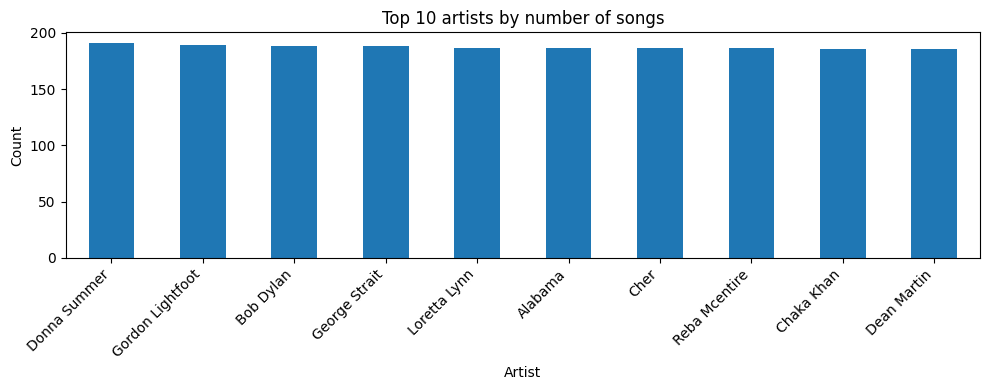

In [ ]:
# Quick EDA: top artists
top_artists = df["artist"].value_counts().head(10)
print("Top 10 artists:")
print(top_artists)

plt.figure(figsize=(10, 4))
top_artists.plot(kind="bar")
plt.title("Top 10 artists by number of songs")
plt.xlabel("Artist")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 2. Text preprocessing

In [ ]:
def preprocess_text(text: str) -> str:
    text = str(text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [tok for tok in tokens if tok not in stop_words and len(tok) > 1]
    return " ".join(tokens)

df["cleaned_text"] = df["text"].astype(str).apply(preprocess_text)
df[["artist", "song", "cleaned_text"]].head()

,artist,song,cleaned_text
0,ABBA,Ahe's My Kind Of Girl,look face wonderful face means something special look way smiles sees lucky one fellow kind girl makes feel fine cou...
1,ABBA,"Andante, Andante",take easy please touch gently like summer evening breeze take time make slow andante andante let feeling grow make f...
2,ABBA,As Good As New,never know go put lousy rotten show boy tough packing stuff saying need anymore enough look standing cause found lif...
3,ABBA,Bang,making somebody happy question give take learn show come give break every smile every little touch know mean much sw...
4,ABBA,Bang-A-Boomerang,making somebody happy question give take learn show come give break every smile every little touch know mean much sw...


In [ ]:
# Save processed lyrics for reuse
output_dir = Path("data_parquet")
output_dir.mkdir(parents=True, exist_ok=True)

lyrics_parquet_path = output_dir / "lyrics_clean.parquet"
df.to_parquet(lyrics_parquet_path, index=False)

print("Saved cleaned lyrics to:", lyrics_parquet_path)
print("Rows:", len(df))

Saved cleaned lyrics to: data_parquet/lyrics_clean.parquet
Rows: 57650


## 3. Baseline recommender: TF-IDF on lyrics

A full pairwise similarity matrix over the entire dataset can be extremely large,  
so for the baseline notebook demo we use a manageable sample.


In [ ]:
BASELINE_SAMPLE_SIZE = min(10000, len(df))
baseline_df = df.sample(BASELINE_SAMPLE_SIZE, random_state=42).reset_index(drop=True)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
baseline_tfidf = tfidf_vectorizer.fit_transform(baseline_df["cleaned_text"])

baseline_cosine_sim = cosine_similarity(baseline_tfidf, baseline_tfidf)

print("baseline_df shape:", baseline_df.shape)
print("TF-IDF matrix shape:", baseline_tfidf.shape)
print("Cosine similarity shape:", baseline_cosine_sim.shape)

baseline_df shape: (10000, 4)
TF-IDF matrix shape: (10000, 5000)
Cosine similarity shape: (10000, 10000)


In [ ]:
def recommend_songs_tfidf(song_name, df_=baseline_df, cosine_sim_=baseline_cosine_sim, top_n=5):
    matches = df_[df_["song"].str.lower() == song_name.lower()]
    if matches.empty:
        return "Song not found in the TF-IDF sample."

    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim_[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # skip self
    sim_scores = [(i, s) for i, s in sim_scores if i != idx][:top_n]
    song_indices = [i for i, _ in sim_scores]

    result = df_.loc[song_indices, ["artist", "song"]].copy()
    result["similarity"] = [score for _, score in sim_scores]
    return result.reset_index(drop=True)

# Example:
# recommend_songs_tfidf("Imagine", top_n=5)

## 4. Multilingual embeddings

This follows the sprint plan: use a pretrained multilingual embedding model rather than training from scratch.


In [ ]:
# Optional dependency install helper
def ensure_package(pkg_name, import_name=None):
    import importlib
    import subprocess
    import sys

    import_name = import_name or pkg_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f"Installing {pkg_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg_name])
        return importlib.import_module(import_name)


In [ ]:
SentenceTransformer = ensure_package("sentence-transformers", "sentence_transformers").SentenceTransformer

MULTILINGUAL_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(MULTILINGUAL_MODEL)
print("Loaded model:", MULTILINGUAL_MODEL)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded model: paraphrase-multilingual-MiniLM-L12-v2


In [ ]:
# Build embeddings on a sampled subset to keep notebook practical
EMBEDDING_SAMPLE_SIZE = min(50000, len(df))
df_for_emb = df.sample(EMBEDDING_SAMPLE_SIZE, random_state=42).reset_index(drop=True)

texts = df_for_emb["cleaned_text"].fillna("").astype(str).tolist()

lyrics_embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,
)
lyrics_embeddings = np.asarray(lyrics_embeddings, dtype=np.float32)

np.save(output_dir / "lyrics_embeddings_multilingual.npy", lyrics_embeddings)
df_for_emb.to_parquet(output_dir / "lyrics_metadata_for_embeddings.parquet", index=False)

print("Embedding matrix shape:", lyrics_embeddings.shape)
print("Saved embedding artifacts in:", output_dir)

Batches:   0%|          | 0/782 [00:00<?, ?it/s]

Embedding matrix shape: (50000, 384)
Saved embedding artifacts in: data_parquet


## 5. FAISS retrieval

Instead of computing all pairwise similarities, we index embeddings and perform efficient nearest-neighbor search.


In [ ]:
faiss = ensure_package("faiss-cpu", "faiss")

d = lyrics_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(d)   # cosine similarity after normalization

emb = lyrics_embeddings.copy().astype(np.float32)
faiss.normalize_L2(emb)
faiss_index.add(emb)

print("FAISS index size:", faiss_index.ntotal)
print("Embedding dimension:", d)

Installing faiss-cpu ...
FAISS index size: 50000
Embedding dimension: 384


In [ ]:
def recommend_songs_multilingual(song_name, df_=df_for_emb, top_n=5):
    matches = df_[df_["song"].str.lower() == song_name.lower()]
    if matches.empty:
        return "Song not found in the multilingual sample."

    pos = matches.index[0]
    query_vec = emb[pos:pos+1].astype(np.float32)
    distances, indices = faiss_index.search(query_vec, top_n + 1)

    recs = []
    for idx, score in zip(indices[0], distances[0]):
        if idx == pos:
            continue
        recs.append((idx, float(score)))
        if len(recs) == top_n:
            break

    result = df_.iloc[[idx for idx, _ in recs]][["artist", "song"]].copy()
    result["score"] = [score for _, score in recs]
    return result.reset_index(drop=True)


def search_by_prompt(prompt, top_n=10, df_=df_for_emb):
    q = model.encode([prompt], normalize_embeddings=True)
    q = np.asarray(q, dtype=np.float32)
    faiss.normalize_L2(q)

    distances, indices = faiss_index.search(q, top_n)
    result = df_.iloc[indices[0]][["artist", "song"]].copy()
    result["score"] = distances[0]
    return result.reset_index(drop=True)

# Examples:
# recommend_songs_multilingual("Imagine", top_n=5)
# search_by_prompt("sad romantic acoustic song", top_n=5)

## 6. XAI layer: explain why a song was recommended

We compare the strongest overlapping TF-IDF terms between a seed song and a recommended song.


In [ ]:
def explain_recommendation(seed_song, recommended_song, df_=baseline_df, vectorizer=tfidf_vectorizer, matrix=baseline_tfidf, top_k_terms=8):
    seed_match = df_[df_["song"].str.lower() == seed_song.lower()]
    rec_match = df_[df_["song"].str.lower() == recommended_song.lower()]

    if seed_match.empty or rec_match.empty:
        return "Seed song or recommended song not found in the TF-IDF sample."

    i = seed_match.index[0]
    j = rec_match.index[0]

    seed_vec = matrix[i].toarray().ravel()
    rec_vec = matrix[j].toarray().ravel()

    shared_strength = seed_vec * rec_vec
    top_indices = np.argsort(shared_strength)[::-1]
    feature_names = np.array(vectorizer.get_feature_names_out())

    top_terms = [feature_names[idx] for idx in top_indices if shared_strength[idx] > 0][:top_k_terms]

    if not top_terms:
        return f'The songs are similar overall, but there are no strong shared lyric keywords in the sampled vocabulary.'

    return (
        f'Both "{seed_song}" and "{recommended_song}" are similar because they strongly overlap on lyric themes such as: '
        + ", ".join(top_terms) + "."
    )

# Example:
# explain_recommendation("Imagine", "Jealous Guy")

## 7. futurescope - (not doing it for CS5100 proj) audio-feature alignment and hybrid recommender

If you have a Spotify audio features file, place it at:

`data_parquet/spotify_audio_features.parquet`

Recommended columns:
- `artist`
- `song`
- `tempo`
- `energy`
- `valence`
- optional: `danceability`, `acousticness`, `instrumentalness`, `liveness`, `speechiness`


In [ ]:
audio_parquet_path = output_dir / "spotify_audio_features.parquet"
hybrid_df = None
audio_feature_cols = None
hybrid_matrix = None
hybrid_cosine_sim = None

if audio_parquet_path.exists():
    audio_df = pd.read_parquet(audio_parquet_path)

    common_cols = ["artist", "song"]
    hybrid_df = pd.merge(df, audio_df, on=common_cols, how="inner")

    candidate_audio_cols = [
        "tempo", "energy", "valence", "danceability",
        "acousticness", "instrumentalness", "liveness", "speechiness"
    ]
    audio_feature_cols = [c for c in candidate_audio_cols if c in hybrid_df.columns]

    if len(audio_feature_cols) < 3:
        raise ValueError(
            "Audio file was found, but not enough usable audio columns were present. "
            f"Found only: {audio_feature_cols}"
        )

    hybrid_df = hybrid_df.reset_index(drop=True)

    hybrid_tfidf_vectorizer = TfidfVectorizer(max_features=5000)
    hybrid_tfidf = hybrid_tfidf_vectorizer.fit_transform(hybrid_df["cleaned_text"])

    audio_features = hybrid_df[audio_feature_cols].fillna(0.0).values
    scaler = StandardScaler()
    audio_features_scaled = scaler.fit_transform(audio_features)

    hybrid_matrix = sparse.hstack([hybrid_tfidf, sparse.csr_matrix(audio_features_scaled)])
    hybrid_cosine_sim = cosine_similarity(hybrid_matrix, hybrid_matrix)

    print("Audio df shape:", audio_df.shape)
    print("Merged hybrid_df shape:", hybrid_df.shape)
    print("Using audio columns:", audio_feature_cols)
    print("Hybrid matrix shape:", hybrid_matrix.shape)
else:
    print(f"Optional file not found: {audio_parquet_path}")
    print("Skipping hybrid lyrics+audio section for now.")

Optional file not found: data_parquet/spotify_audio_features.parquet
Skipping hybrid lyrics+audio section for now.


In [ ]:
def recommend_songs_hybrid(song_name, df_, cosine_sim_, audio_cols, top_n=5):
    matches = df_[df_["song"].str.lower() == song_name.lower()]
    if matches.empty:
        return "Song not found in the hybrid dataset."

    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim_[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = [(i, s) for i, s in sim_scores if i != idx][:top_n]
    song_indices = [i for i, _ in sim_scores]

    result = df_.loc[song_indices, ["artist", "song"] + audio_cols].copy()
    result["similarity"] = [score for _, score in sim_scores]
    return result.reset_index(drop=True)

# Example:
# if hybrid_df is not None:
#     test_song = hybrid_df["song"].iloc[0]
#     display(recommend_songs_hybrid(test_song, hybrid_df, hybrid_cosine_sim, audio_feature_cols, top_n=5))

## 8. Context-aware filtering

This implements the sprint idea of lightweight hard filters.  
Example: if the user is in a **gym** context, prefer high-energy songs.


In [ ]:
def recommend_for_context(song_name, context="default", top_n=5):
    if hybrid_df is None or hybrid_cosine_sim is None:
        return "Context-aware filtering requires the optional hybrid audio dataset."

    base = recommend_songs_hybrid(song_name, hybrid_df, hybrid_cosine_sim, audio_feature_cols, top_n=50)
    if isinstance(base, str):
        return base

    result = base.copy()

    if context.lower() == "gym" and "energy" in result.columns:
        result = result[result["energy"] > 0.7]

    if context.lower() == "calm" and "acousticness" in result.columns:
        result = result.sort_values("acousticness", ascending=False)

    return result.head(top_n).reset_index(drop=True)

# Example:
# recommend_for_context("Imagine", context="gym", top_n=5)

## 9. Optional 3D visualization with UMAP + Plotly

This cell is optional and may take some time.  
It visualizes a subset of the embedding space in 3D.


In [ ]:
umap = ensure_package("umap-learn", "umap")
plotly_express = ensure_package("plotly", "plotly.express")

viz_size = min(1000, len(df_for_emb))
viz_df = df_for_emb.sample(viz_size, random_state=42).reset_index(drop=True)
viz_idx = viz_df.index.to_numpy()

# Because viz_df was resampled from df_for_emb, remap by merge on keys
viz_join = viz_df.merge(
    df_for_emb.reset_index().rename(columns={"index": "emb_idx"})[["emb_idx", "artist", "song"]],
    on=["artist", "song"],
    how="left"
)
viz_emb = emb[viz_join["emb_idx"].values]

reducer = umap.UMAP(n_components=3, random_state=42)
coords = reducer.fit_transform(viz_emb)

viz_plot_df = viz_df[["artist", "song"]].copy()
viz_plot_df["x"] = coords[:, 0]
viz_plot_df["y"] = coords[:, 1]
viz_plot_df["z"] = coords[:, 2]

fig = plotly_express.scatter_3d(
    viz_plot_df,
    x="x", y="y", z="z",
    hover_name="song",
    hover_data=["artist"],
    title="3D UMAP of multilingual song embeddings"
)
fig.show()

## 10. Demo cells

In [ ]:
# adding cases for demo in terminal

## 11. What is now completed

This notebook now covers the sprint plan in a practical way:

- **FAISS integration and scalable search**
- **Multilingual sentence-transformer embeddings**
- **Lyrics + audio hybrid recommendation**
- **Context-aware filtering**
- **Explainability**
- **3D visualization**

For a final project submission, the next logical step would be to wrap these functions inside a **Streamlit UI** and add a short **demo video + documentation**.
